# Imports

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from pathlib import Path

import scienceplots
plt.style.use(['science', 'grid'])

# Set global error handling for NumPy
np.seterr(invalid='ignore', divide='ignore')

from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED, FAC, T_SOLIDUS, T_LIQUIDUS, 
)
from TherMIFASOL.core.variables.BoardCardFilterVariable import (
    params_clip, boundaries_data_selection
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters, plot_temperature_evolution, plot_thermal_images,
    create_csv_file
)
from TherMIFASOL.core.utils.ImageProcessing import (
    get_video_from_images
)

In [ ]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


data_path_CRED = os.path.join(
    PATH_DATA, "experiences/BoardCardFilter/DEC1/CRED/data"
)
data_path_pyrometer = os.path.join(
    PATH_DATA, "experiences/BoardCardFilter/DEC1/pyrometer/"
)

array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp500__diaphMIN_bois2.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT100_deg1_diaphMIN_bois2_TRUSTWORTHY.npy"
        )
    )

saving_path = os.path.join(BASE_DIR, "results/BoardFilter/homogenous")

# Pyrometer wake
- The pyrometer is focused on a single, specific point on the wall. However, the melt pool moves along this wall during the deposition process. To simulate the pyrometer's effective recording when the melt pool passes through its observation point, we adjust the observation point in the image.

- Instead of capturing the melt pool as it naturally passes through the observation point, we shift the observation point in the image by the relative displacement speed. This adjustment mimics the pyrometer's recording as if the melt pool were actually moving through its fixed observation area.

- The relative path of the pyrometer created by this adjustment is called the "pyrometer wake."

- The concept of pyrometer wake relies on the assumption that the thermal field maintains a steady-state shape throughout the deposition of a single bead.

In [11]:
hauteur = int(0.8/FAC)  # Pyrometer spot size is 0.8 mm 
lim_sup_mm = 7.5
lim_sup = int((19.2-lim_sup_mm)/19.2*512 )

pyrometer_wake = np.zeros((LINES_CRED, COLUMNS_CRED, 4))
pyrometer_wake[lim_sup:lim_sup+hauteur,:,:]=1
pyrometer_wake[lim_sup:lim_sup+hauteur,:,3]=0.5

# Compare emissivity
This section focuses on the sensitivity of thermal field according to the emissivity factor.

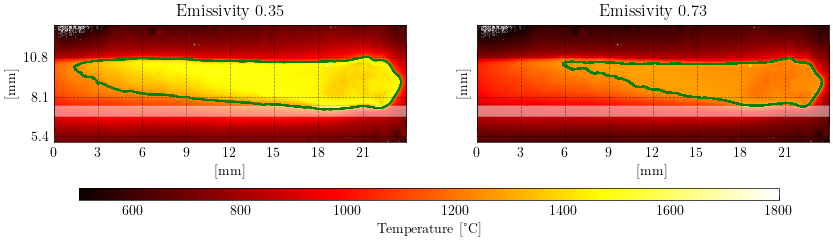

In [12]:
# Constants
c_cordon = 14
id_img = params_clip[c_cordon]['snapshot']

# Paths
path_raw_data_layer = os.path.join(data_path_CRED, f"layer_{c_cordon}")

# Coefficients
coefficient_1 = 0.35
coefficient_2 = 0.73

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

# Plot setup
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharex=True, sharey=True)

# Load data
dl_raw = load_cred_array(os.path.join(path_raw_data_layer, f"im_{id_img}.npy"))

# Process and plot for each coefficient
for idx, eps in enumerate([coefficient_1, coefficient_2]):
    col = idx % 2

    # Convert raw data to thermal image
    im_thermo = np.flipud(dl_to_thermo(
        dl_raw=dl_raw,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=eps))

    # Find contours
    contours = measure.find_contours(im_thermo, T_SOLIDUS)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

    # Plot thermal image
    im = axes[col].imshow(im_thermo - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

    # Overlay pyrometer wake
    axes[col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Set ticks and labels
    axes[col].set_xticks(xtick_pixels * FAC)
    axes[col].set_yticks(ytick_pixels * FAC)
    axes[col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    # Axis labels and limits
    axes[col].set_xlabel('[mm]')
    axes[col].set_ylabel('[mm]')
    axes[col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[col].set_ylim(0, (LINES_CRED - 1) * FAC)

    # Crop limits
    crop_min = params_clip[c_cordon]['crop low']
    crop_max = params_clip[c_cordon]['crop high']
    axes[col].set_ylim(crop_min, crop_max)

    # Title
    axes[col].set_title(f"Emissivity {eps}")

    # Plot contours
    for contour in contours:
        axes[col].plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='green', linewidth=1)

    axes[col].tick_params(axis='both', which='both', length=0)

# Colorbar setup
cbar_ax = fig.add_axes([0.15, 0.3, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature [°C]')
del dl_raw
# Display plot
plt.show()

# One bead movie creation

## First step
Save successive images as following "../resultats/tempor/image_{img+1:03d}.png"

In [13]:
# Constants
ID_LAYER = 15
FRAME_EACH = 3
ID_FIRST_FRAME = params_clip[ID_LAYER]['start frame']
ID_LAST_FRAME = params_clip[ID_LAYER]['end frame']
CROP_MIN = params_clip[ID_LAYER]['crop low']  # Minimum value in mm for Y
CROP_MAX = params_clip[ID_LAYER]['crop high']  # Maximum value in mm for Y
FPS = int(params_clip[ID_LAYER]['FPS estimate']/FRAME_EACH)  # Frames per second
EMISSIVITY_CONSTANT = 0.73
STR_TITLE_GRAPH = f"Emissivity field uniform of {EMISSIVITY_CONSTANT}"

# Paths
path_raw_data_layer = os.path.join(data_path_CRED, f"layer_{ID_LAYER}/")
PATH_DIRECTORY_IMAGES = os.path.join(saving_path, f"uniform_emissivity_cordon_{ID_LAYER}") 
if not os.path.exists(PATH_DIRECTORY_IMAGES + '/images'):
    os.makedirs(PATH_DIRECTORY_IMAGES + '/images')

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent, xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

# Process each frame and write to video
for img in np.arange(ID_FIRST_FRAME, ID_LAST_FRAME)[::FRAME_EACH]:
    arr = load_cred_array(os.path.join(path_raw_data_layer, f"im_{img}.npy"))

    # Convert raw data to thermal image
    im_thermo = np.flipud(dl_to_thermo(
        dl_raw=arr,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=eps))

    # Find contours
    contours = measure.find_contours(im_thermo, T_SOLIDUS)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

    # Plot setup
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(symmetrical_contour[:, 1] * FAC, symmetrical_contour[:, 0] * FAC, color='g', lw=2, label="Outer Contour")

    # Display thermal image
    im = ax.imshow(im_thermo - 273.15, interpolation='nearest', vmin=600, vmax=1400, cmap=plt.cm.gray, extent=extent)
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', shrink=1.1)
    cbar.ax.hlines(T_SOLIDUS, xmin=0, xmax=1, colors='g', linewidth=3, label=f'T_solidus = {T_SOLIDUS}°C')
    cbar.set_label('Temperature [°C]')
    ax.set_title(STR_TITLE_GRAPH)

    # Axis ticks and labels
    ax.set_xticks(xtick_pixels * FAC)  # Convert to mm for ticks
    ax.set_yticks(ytick_pixels * FAC)
    ax.set_xticklabels([f"{x:.1f}" for x in xtick_pixels * FAC])  # Convert to mm for labels
    ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    # Axis labels and limits
    ax.set_xlabel('[mm]')
    ax.set_ylabel('[mm]')
    ax.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    ax.set_ylim(0, (LINES_CRED - 1) * FAC)
    ax.set_ylim(CROP_MIN, CROP_MAX)  # Crop in mm

    # Save the plot
    output_path = os.path.join(PATH_DIRECTORY_IMAGES + '/images', f"image_{img+1:03d}.png")  # Filename with numbering
    plt.savefig(output_path, dpi=300)  # Save the image
    plt.close(fig)

get_video_from_images(
    image_folder=PATH_DIRECTORY_IMAGES + '/images',
    output_video=os.path.join(PATH_DIRECTORY_IMAGES, f"video_FPS{FPS}.mp4"),
    fps=FPS
)

Vidéo générée : /home/dolle/Documents/3_These doctorat/6_python/Thermique MIFASOL/results/BoardFilter/uniform_emissivity_cordon_15/video_FPS165.mp4


# One moment : six images a row
Six images are chosen among the 11 to 16 layers according to the 'id_chosen' into the dictionary params_clip in params.py file

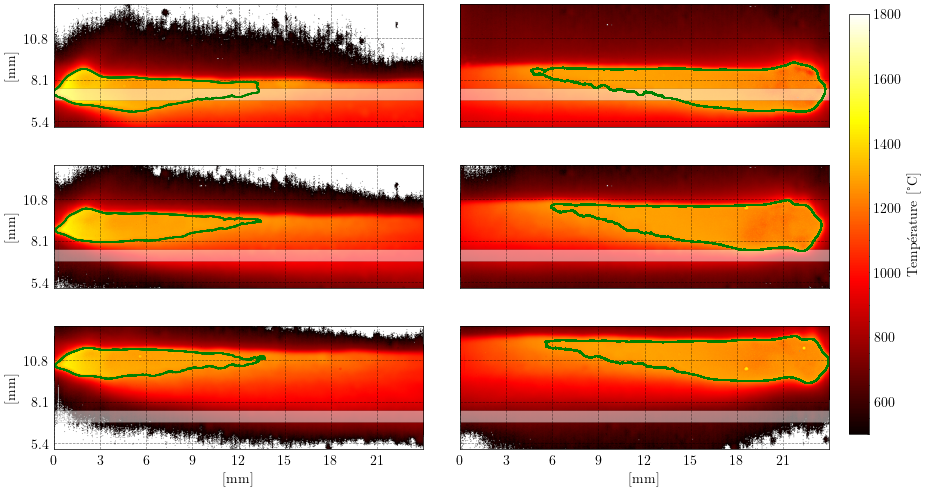

In [14]:
# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent, xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 6), sharex=True, sharey=True)

for idx, c_cordon in enumerate(np.arange(11, 17)):
    row = idx // 2  # Ligne de l'axe (0, 1, 2)
    col = idx % 2   # Colonne de l'axe (0, 1)

    # Load raw data
    img_to_display = params_clip[c_cordon]['snapshot']
    path_raw_data_img = os.path.join(data_path_CRED, f"layer_{c_cordon}/im_{img_to_display}.npy")
    dl_raw = load_cred_array(path_raw_data_img)

    # Convert raw data to thermal image
    im_thermo = np.flipud(dl_to_thermo(
        dl_raw=dl_raw,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=eps))
    contours = measure.find_contours(im_thermo, T_SOLIDUS)

    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symétrie sur l'axe Y

    im = axes[row, col].imshow(im_thermo-273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)
    
    # Sillage pyromètre
    axes[row, col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    axes[row, col].set_xticks(xtick_pixels)
    axes[row, col].set_yticks(ytick_pixels)
    
    axes[row, col].set_xticks(xtick_pixels * FAC)  # Conversion en mm pour les ticks
    axes[row, col].set_yticks(ytick_pixels * FAC)
    axes[row, col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])  # Conversion en mm pour les labels
    axes[row, col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])
    
    # Ajustement des axes
    if row ==2:
        axes[row, col].set_xlabel('[mm]')
    if col%2 ==0:
        axes[row, col].set_ylabel('[mm]')
    axes[row, col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[row, col].set_ylim(0, (LINES_CRED - 1) * FAC)
    
    crop_min = params_clip[c_cordon]['crop low']  # Valeur minimum en mm pour Y
    crop_max = params_clip[c_cordon]['crop high']  # Valeur maximum en mm pour Y
    axes[row, col].set_ylim(crop_min, crop_max)  # Recadrage en mm
    # axes[row, col].set_title(f"Image {idx+1}")  # Titre pour chaque sous-graphique
    
    for contour in contours:
        axes[row, col].plot(FAC*symmetrical_contour[:, 1], FAC*symmetrical_contour[:, 0], color='green', linewidth=1)
    axes[row, col].tick_params(axis='both', which='both', length=0)

# Création d'un axe pour la colorbar sur le côté
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position (x, y, largeur, hauteur)

# Ajout de la colorbar
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
norm = plt.Normalize(vmin=500, vmax=1800)  # Normalisation manuelle pour correspondre à imshow
cbar_ax.imshow([[500, 1800]], cmap='inferno', norm=norm, aspect='auto', visible=False)  # Force la normalisation
solidus_norm = (T_SOLIDUS - 500) / (1800 - 500)  # Normalisation de Tsolidus entre 0 et 1
cbar.ax.set_ylim(500, 1800)
cbar.ax.axhline(y=solidus_norm, color='g', linewidth=3, linestyle="--")
cbar.set_label('Température [°C]')

plt.subplots_adjust(right=0.9, hspace=0.15, wspace=0.1)
# plt.tight_layout()
# plt.savefig("../resultats/resultat_thermique.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

# Find framerate 
- $v = \frac{d}{t}$ => $t = \frac{d}{v}$ 
- $FPS = \frac{frames}{t}$
- suivi du pixel détecté du solidus le plus en amont du bain de fusion: évolution linéaire de ce dernier quaisment sans bruit. Permet de suivre l'avancée de la buse.
- 600 pixels sont parcourus en 665 frames soit 22.5 mm en 665 frames.
- Le temps de parcours de la buse pour 22.5mm est de 1.347s ($t = \frac{22.5}{16.7}$)
- Donc la fréquence d'acquisition de la caméra est de $\frac{665}{1.347} = 493.6$

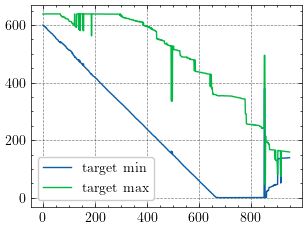

In [15]:
c_cam = 11
store_min, store_max = [], []
for id_choose in range(params_clip[c_cam]['start frame'] , params_clip[c_cam]['end frame']):
    
    # Load raw data
    path_raw_data_img = os.path.join(data_path_CRED, f"layer_{c_cam}/im_{id_choose}.npy")
    dl_raw = load_cred_array(path_raw_data_img)

    # Turn thermal image
    im_thermo = np.flipud(dl_to_thermo(
        dl_raw=dl_raw,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=eps))
    
    # Find contours
    contours = measure.find_contours(im_thermo, T_SOLIDUS)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)

    # Target extremum
    store_min.append(np.min(largest_contour[:,1]))
    store_max.append(np.max(largest_contour[:,1]))

# Display
plt.plot(store_min, label='target min')
plt.plot(store_max, label='target max')
plt.legend()
plt.show()

In [16]:
# cordon   :   11   |   12   |   13   |   14   |   15   |   16   |

# pix      :  600   |  274   |   90   |   182  |  179   |  368   |
# mm       :  22.5  | 10.275 |  3.375 |  6.825 | 6.712  |  13.8  |
# sec      :  1.347 | 0.615  |  0.20  |  0.407 | 0.402  | 0.8263 |

# frames   :  665   |  300   |  100   |  200   |  200   |  400   |

# FPS cam  : 493.6  | 487.6  |  495.0 | 491.4  | 497.5  |  484.1 |

# FPS mean : 491

# Overlaying pyrometer and camera readings

## Static image

Layers selection

In [17]:
cordons_selection = [11, 12, 13, 14, 15, 16]
emissivity_coefficient = 0.73
upper_limit_pyrometer_wake = 8.1

Pyrometer data selection

In [18]:
DATA = {id_:{} for id_ in cordons_selection}

for cordon in cordons_selection:
    # Get pyrometer data of the layer recording
    csv_path_pyrometer_data = os.path.join(data_path_pyrometer, f"WLAM_H322_14150_{cordon}.csv")
    INFO = collect_data_pyrometer(csv_path=csv_path_pyrometer_data)

    low_boundary, _ = boundaries_data_selection[cordon]
    mask = INFO['array time'] > low_boundary

    DATA[cordon]['array time'] = INFO['array time'][mask] - low_boundary
    DATA[cordon]['array MAtemp2C'] = INFO['array MAtemp2C'][mask]
    DATA[cordon]['array MAemissivity'] = INFO['array MAemissivity'][mask]

Camera data selection

In [19]:
LIST_THERMAL_IMAGES = []
CAMERA_DATA_PYROMETER_SAKE = {}
lim_sup = int((19.2 - upper_limit_pyrometer_wake) / 19.2 * 512)

for c_cordon in cordons_selection:
    # Load raw data
    img_to_display = params_clip[c_cordon]['snapshot']
    path_raw_data_img = os.path.join(data_path_CRED, f"layer_{c_cordon}/im_{img_to_display}.npy")
    dl_raw = load_cred_array(path_raw_data_img)

    # Convert raw data to thermal image
    im_thermo = np.flipud(dl_to_thermo(
        dl_raw=dl_raw,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=emissivity_coefficient)) - 273.15

    LIST_THERMAL_IMAGES.append(im_thermo)
    temperature_evolution = [np.nanmean(im_thermo[lim_sup:lim_sup + 22, i:i + 22]) for i in range(COLUMNS_CRED)]
    temperature_evolution = np.asarray(temperature_evolution)
    time_evolution = np.arange(temperature_evolution.size) / params_clip[c_cordon]['FPS estimate']

    CAMERA_DATA_PYROMETER_SAKE[c_cordon] = {
        'temperature [C]': temperature_evolution,
        'time': time_evolution
    }


/tmp/ipykernel_45374/349065679.py:19: RuntimeWarning: Mean of empty slice
  temperature_evolution = [np.nanmean(im_thermo[lim_sup:lim_sup + 22, i:i + 22]) for i in range(COLUMNS_CRED)]


Plot graphs

In [20]:
save_path=os.path.join(saving_path, f"overlay/")

In [24]:
# Pyrometer
plot_temperature_evolution(
    save_path=save_path,
    cordons_selection=cordons_selection, 
    SILLAGE_PYRO_CAMERA=CAMERA_DATA_PYROMETER_SAKE, 
    boundaries_data_selection=boundaries_data_selection, 
    DATA=DATA,
    limit_wake=upper_limit_pyrometer_wake,
    emissivity_factor=emissivity_coefficient,
    Tliquidus=T_SOLIDUS-273.15, 
    Tsolidus=T_LIQUIDUS-273.15
    )

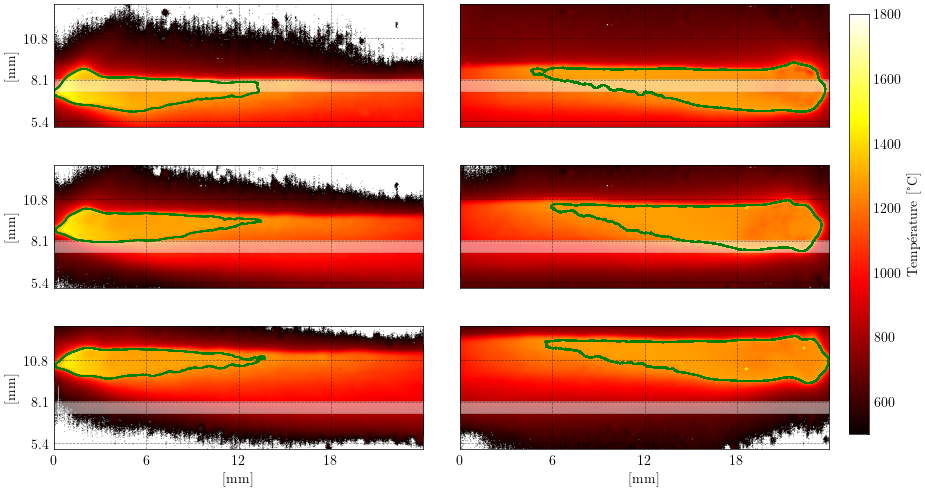

In [22]:
# Camera
plot_thermal_images(
    save_path=None, 
    limit_wake=upper_limit_pyrometer_wake, 
    list_thermal_images=LIST_THERMAL_IMAGES, 
    cordon_selection=cordons_selection, 
    params_clip=params_clip, 
    Tsolidus=T_SOLIDUS-273.15, 
    fac=FAC, 
    COLUMNS=COLUMNS_CRED, 
    LINES=LINES_CRED
    )

In [25]:
create_csv_file(
    save_path=os.path.join(saving_path, f"overlay/"), 
    cordons_selection=cordons_selection, 
    DATA=DATA, 
    SILLAGE_PYRO_CAMERA=CAMERA_DATA_PYROMETER_SAKE
)

CSV files created for cordon 11.
CSV files created for cordon 12.
CSV files created for cordon 13.
CSV files created for cordon 14.
CSV files created for cordon 15.
CSV files created for cordon 16.
